# Анализ рынка недвижимости Санкт-Петербурга

**Исследовательский анализ данных (EDA)**

---

## О проекте

Данный проект представляет собой исследовательский анализ данных объявлений о продаже квартир, опубликованных на сервисе Яндекс Недвижимость. В датасете собраны объявления по Санкт-Петербургу и ближайшим населённым пунктам за несколько лет (2014–2019).

**Цель:** выявить факторы, влияющие на рыночную стоимость жилья, и установить параметры, необходимые для построения автоматизированной системы обнаружения аномалий и мошеннической деятельности.

**Источник данных:** архив объявлений сервиса Яндекс Недвижимость. По каждому объекту доступны два вида данных: введённые пользователем вручную (площадь, число комнат, цена) и рассчитанные автоматически на основе картографических данных (расстояние до центра, аэропорта, парков, водоёмов).

**Структура проекта:**
1. [Изучение данных](#1)
2. [Предобработка данных](#2)
3. [Инженерия признаков](#3)
4. [Исследовательский анализ данных](#4)
5. [Анализ зависимости цены от параметров](#5)
6. [Географический анализ](#6)
7. [Анализ центрального сегмента](#7)
8. [Общие выводы](#8)


<a id="1"></a>
## 1. Изучение данных

Загружаем библиотеки и читаем данные. Первичный осмотр: размерность, типы столбцов, базовая статистика, наличие пропусков.

In [3]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('real_estate_data (2).csv', delimiter='\t')

print('Размер датасета:', df.shape)
print()
print('Первые строки:')
display(df.head())
print()
print('Типы данных и пропуски:')
df.info()
print()
print('Базовая статистика:')
display(df.describe())
print()
print(f'Медианная цена: {df["last_price"].median():,.0f} ₽')

### Вывод

Датасет содержит **23 699 записей** по **22 признакам**: стоимость, характеристики квартиры (площадь, число комнат, этаж, высота потолков), данные о местоположении (расстояния до центра, аэропорта, парков) и временны́е метки публикации.

Выявленные проблемы, требующие предобработки:

- **Тип данных:** `first_day_exposition` хранится как `object`, хотя содержит дату — нужно привести к `datetime`.
- **Критичные пропуски:** `is_apartment` — 88% пропусков, `parks_nearest` — 66%, `ponds_nearest` — 62%. Восстановить их без искажений невозможно.
- **Умеренные пропуски:** `ceiling_height`, `floors_total`, `living_area`, `kitchen_area` — заполним медианой.
- **Выбросы** (выявлены через `describe()`): `ceiling_height` max = 100 м, `last_price` max = 763 млн ₽ (медиана ~4.65 млн), `total_area` max = 900 м², `total_rooms` max = 19 — требуют обработки на этапе EDA.


<a id="2"></a>
## 2. Предобработка данных

Заполняем пропуски, исправляем типы данных. Выбор метода заполнения обоснован для каждого столбца отдельно.

In [ ]:
# Заполняем пропуски медианой для числовых столбцов с умеренным количеством пропусков.
# Медиана устойчива к выбросам — предпочтительнее среднего для скошенных распределений.
medians = df[['ceiling_height', 'floors_total', 'living_area', 'kitchen_area']].median()
df.fillna(medians, inplace=True)

# Балкон: отсутствие значения интерпретируем как отсутствие балкона (0).
# Решение спорное — пользователь мог не заполнить поле, — но альтернативы нет.
df['balcony'] = df['balcony'].fillna(0)

df.info()

In [ ]:
# Исправляем типы данных:
# - floors_total, balcony → int (количество этажей и балконов не может быть дробным)
# - first_day_exposition → datetime (столбец содержит дату, а не строку)
df = df.astype({'floors_total': 'int', 'balcony': 'int'}, errors='ignore')
df['first_day_exposition'] = pd.to_datetime(df['first_day_exposition'], format='%Y-%m-%dT%H:%M:%S')

df.info()

### Вывод

**Что заполнено:**
- `ceiling_height`, `floors_total`, `living_area`, `kitchen_area` → медиана. Метод устойчив к выбросам, но вносит допущение: реальное распределение пропусков по типам квартир неизвестно, что потенциально создаёт смещение.
- `balcony` → 0. Допущение: пропуск = отсутствие балкона.

**Что оставлено с пропусками намеренно:**
- `is_apartment`, геоданные (`airports_nearest`, `parks_nearest`, `ponds_nearest` и др.) — восстановить без риска внести ошибочные данные невозможно.
- `days_exposition` — пропуск несёт смысловую нагрузку: квартира не была продана на момент выгрузки данных (MNAR — Missing Not At Random). Заполнять нельзя.

**Исправлены типы данных:** `first_day_exposition` → `datetime`, `floors_total` и `balcony` → `int`.


<a id="3"></a>
## 3. Инженерия признаков

Создаём новые столбцы, которые понадобятся в ходе анализа: цена за м², дата публикации в разбивке по компонентам, соотношения площадей и тип этажа.

In [ ]:
# Цена за квадратный метр — ключевой показатель для сравнения объектов разной площади
df['price_per_sq_m'] = df['last_price'] / df['total_area']

# Компоненты даты публикации для анализа сезонности
df['weekday'] = df['first_day_exposition'].dt.weekday
df['month']   = df['first_day_exposition'].dt.month
df['year']    = df['first_day_exposition'].dt.year

# Соотношения площадей: сколько жилой/кухонной площади от общей
df['living_to_total_area_ratio']  = df['living_area']  / df['total_area']
df['kitchen_to_total_area_ratio'] = df['kitchen_area'] / df['total_area']

# Тип этажа: первый, последний или средний.
# Выбран подход через именованную функцию вместо lambda — читаемость важнее краткости
# при вложенных тернарных операторах.
def get_floor_type(row):
    if row['floor'] == 1:
        return 'первый'
    elif row['floor'] == row['floors_total']:
        return 'последний'
    else:
        return 'другой'

df['floor_type'] = df.apply(get_floor_type, axis=1)

display(df.head())

<a id="4"></a>
## 4. Исследовательский анализ данных

### 4.1 Первичный осмотр распределений (до удаления выбросов)

Прежде чем фильтровать данные, смотрим на «сырые» распределения — это помогает понять масштаб проблемы с выбросами и выбрать корректный метод их обработки.

In [ ]:
print(df.describe())
print('\nРазмер датасета:', df.shape)

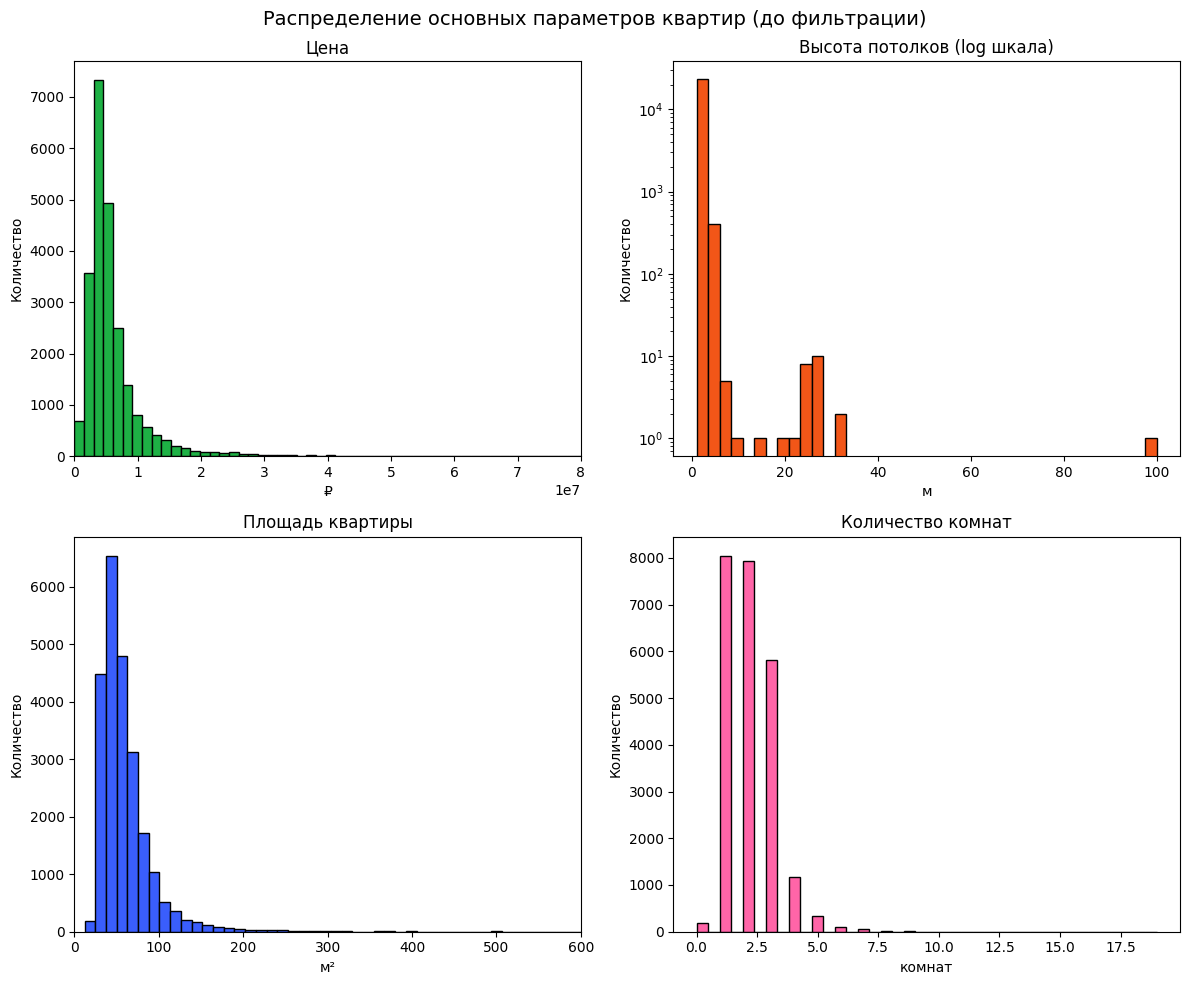

In [10]:
#  Построим гистограммы основных параметров до фильтрации выбросов
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Распределение основных параметров квартир (до фильтрации)', fontsize=14)

# График цены
axes[0, 0].hist(df['last_price'], bins=500, edgecolor='black', color="#1EB145")
axes[0, 0].set_title('Цена')
axes[0, 0].set_xlabel('₽')
axes[0, 0].set_ylabel('Количество')
axes[0, 0].set_xlim(0, 80000000) 

# График площади
axes[1, 0].hist(df['total_area'], bins=70, edgecolor='black', color ="#3A5EFC")
axes[1, 0].set_title('Площадь квартиры')
axes[1, 0].set_xlabel('м²')
axes[1, 0].set_ylabel('Количество')
axes[1, 0].set_xlim(0, 600) 

# График высоты потолков
axes[0, 1].hist(df['ceiling_height'], bins=40, edgecolor='black', color="#F25618")
axes[0, 1].set_title('Высота потолков (log шкала)')
axes[0, 1].set_xlabel('м')
axes[0, 1].set_ylabel('Количество')
axes[0, 1].set_yscale('log')  # используем логарифмическую шкалу, чтобы можно было увидеть редкие значения (а именно квартиру с высотой потолков 100 м)

# График количества комнат
axes[1, 1].hist(df['rooms'], bins=40, edgecolor='black', color="#FF65A8")
axes[1, 1].set_title('Количество комнат')
axes[1, 1].set_xlabel('комнат')
axes[1, 1].set_ylabel('Количество')


plt.tight_layout()
plt.show()

### 4.2 Определение и удаление выбросов

Применяем метод межквартильного размаха (IQR) для площади, цены и числа комнат.  
Для высоты потолков — содержательный порог на основе знания рынка СПб.


In [ ]:
# Рассчитываем IQR-пороги для каждого параметра
for col, label in [('total_area', 'Площадь'), ('last_price', 'Цена'), ('rooms', 'Комнаты')]:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    print(f'{label}: IQR = {IQR:,.1f} | нижний порог = {lower:,.1f} | верхний порог = {upper:,.1f}')

# Рассчитываем пороги отдельно для переменной фильтрации
IQR_area  = df['total_area'].quantile(0.75) - df['total_area'].quantile(0.25)
area_upper_fence  = df['total_area'].quantile(0.75) + 1.5 * IQR_area

IQR_price = df['last_price'].quantile(0.75) - df['last_price'].quantile(0.25)
price_upper_fence = df['last_price'].quantile(0.75) + 1.5 * IQR_price

IQR_rooms = df['rooms'].quantile(0.75) - df['rooms'].quantile(0.25)
rooms_upper_fence = df['rooms'].quantile(0.75) + 1.5 * IQR_rooms

**Почему для потолков не используется IQR?**

IQR для `ceiling_height` равен всего 0.1 м — большинство квартир имеют стандартные 2.65 м. Граница по IQR составила бы ~2.85 м, что отсекло бы более 4 000 нормальных квартир с потолками 3 м (старый фонд, сталинки — характерная черта рынка СПб). Используем содержательный порог:

- Стандарт: панельки — 2.5–2.7 м, кирпич/монолит — 2.7–3.2 м, сталинки — до 3.5–4 м.
- Всё выше 5 м — явная ошибка ввода или нежилое помещение.


In [ ]:
# Количество записей с потолками ≥ 5 м (явные выбросы)
print('Записей с ceiling_height >= 5 м:', df[['ceiling_height']].query('ceiling_height >= 5').count().item())

In [ ]:
# Фильтруем датасет: убираем выбросы по площади, цене, комнатам и потолкам
df_filtered = df.query(
    'total_area <= @area_upper_fence '
    'and ceiling_height <= 5 '
    'and last_price <= @price_upper_fence '
    'and rooms <= @rooms_upper_fence'
)

removed = len(df) - len(df_filtered)
print(f'Удалено записей: {removed} ({removed / len(df) * 100:.1f}%)')
print(f'Осталось записей: {len(df_filtered)}')

In [ ]:
display(df_filtered.describe())

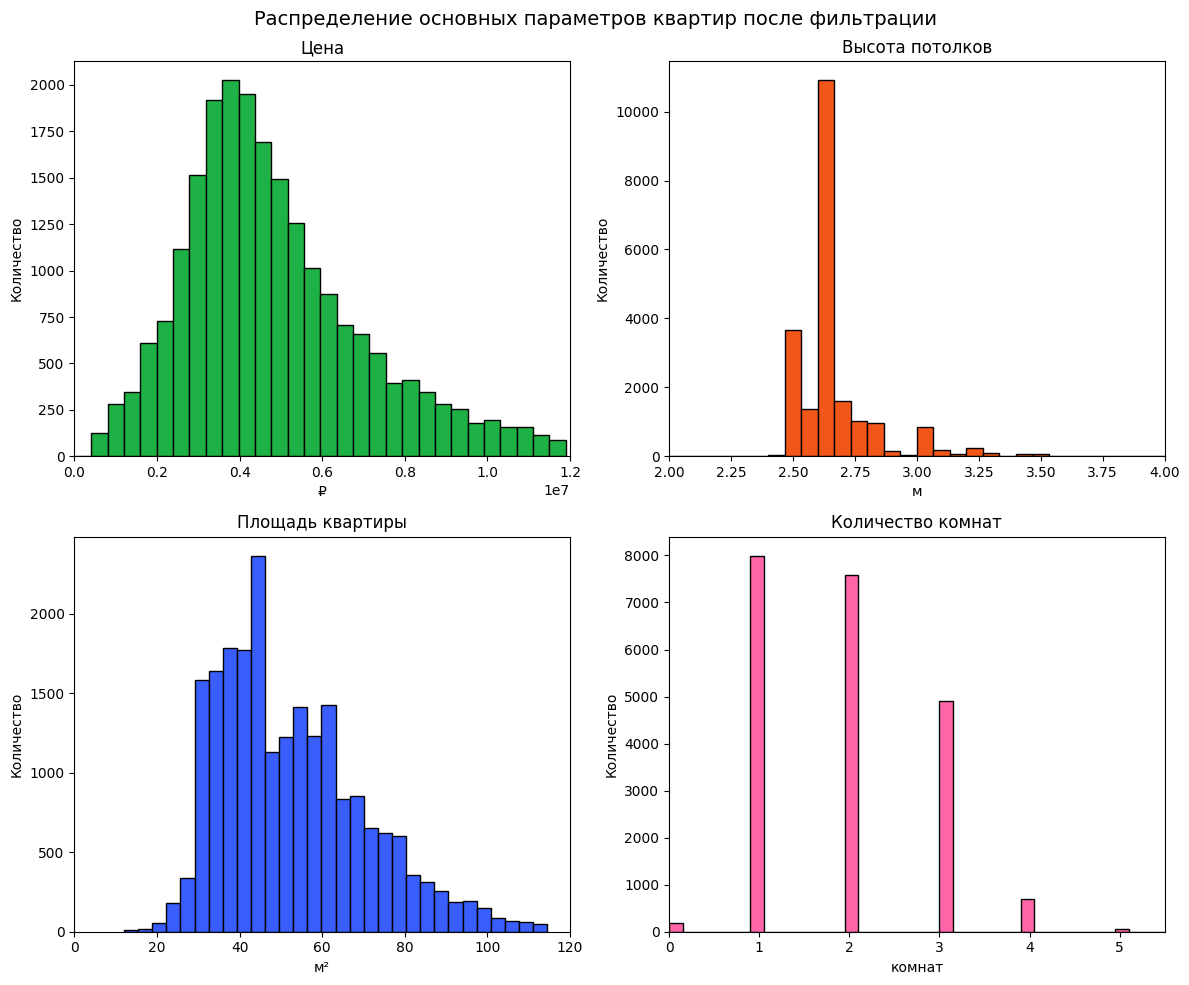

In [15]:
# Построим гистограммы по отфильтрованному датафрейму
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Распределение основных параметров квартир после фильтрации', fontsize=14)

# График цены
axes[0, 0].hist(df_filtered['last_price'], bins=30, edgecolor='black', color="#1EB145")
axes[0, 0].set_title('Цена')
axes[0, 0].set_xlabel('₽')
axes[0, 0].set_ylabel('Количество')
axes[0, 0].set_xlim(0, 12000000) 

# График площади
axes[1, 0].hist(df_filtered['total_area'], bins=30, edgecolor='black', color ="#3A5EFC")
axes[1, 0].set_title('Площадь квартиры')
axes[1, 0].set_xlabel('м²')
axes[1, 0].set_ylabel('Количество')
axes[1, 0].set_xlim(0, 120) 

# График высоты потолков
axes[0, 1].hist(df_filtered['ceiling_height'], bins=60, edgecolor='black', color="#F25618")
axes[0, 1].set_title('Высота потолков')
axes[0, 1].set_xlabel('м')
axes[0, 1].set_ylabel('Количество')
axes[0, 1].set_xlim(2, 4) 

# График количества комнат
axes[1, 1].hist(df_filtered['rooms'], bins=40, edgecolor='black', color="#FF65A8")
axes[1, 1].set_title('Количество комнат')
axes[1, 1].set_xlabel('комнат')
axes[1, 1].set_ylabel('Количество')
axes[1, 1].set_xlim(0, 5.5) 

plt.tight_layout()
plt.show()

### Вывод

**Цены** распределены с правым смещением: большинство объявлений сосредоточено в диапазоне 2–6 млн ₽, пик приходится на 3.5–4.5 млн. Это соответствует массовому сегменту рынка СПб периода 2014–2019 годов.

**Площадь** также имеет правостороннее распределение с пиком в районе 30–45 м² — характерный размер для однокомнатных квартир и студий, которые доминируют в предложении.

**Высота потолков** сконцентрирована в очень узком диапазоне: подавляющее большинство квартир имеет стандартные 2.65 м — типичный показатель для панельных домов советской и постсоветской застройки.

**Число комнат:** рынок делится преимущественно между однокомнатными и двухкомнатными квартирами. Трёхкомнатные представлены скромнее, четырёх- и пятикомнатные — редкость.


### 4.3 Время продажи

Анализируем, как быстро квартиры находят покупателя. Поскольку `days_exposition` содержит пропуски (квартира не продана на момент выгрузки), анализ проводим только по проданным объектам.

In [ ]:
display(df_filtered['days_exposition'].describe())

In [ ]:
plt.figure(figsize=(10, 5))
plt.hist(df_filtered['days_exposition'].dropna(), bins=50, range=(0, 1500), edgecolor='black', color='steelblue')
plt.title('Распределение времени продажи квартиры')
plt.xlabel('Дней на продажу')
plt.ylabel('Количество объявлений')
plt.tight_layout()
plt.show()

In [ ]:
median_days = df_filtered['days_exposition'].median()
mean_days   = df_filtered['days_exposition'].mean()
print(f'Медианное время продажи: {median_days:.0f} дней')
print(f'Среднее время продажи:   {mean_days:.0f} дней')

### Вывод

**Медиана — 91 день, среднее — 172 дня.** Большинство квартир продаются в течение первых 100–200 дней (3–6 месяцев). Среднее выше медианы из-за правого хвоста: небольшая часть объектов «зависает» на рынке надолго.

| Категория | Срок продажи | Вероятная причина |
|-----------|-------------|-------------------|
| Очень быстро | < 45 дней | Конкурентная цена, высокий спрос |
| Быстро | 45–100 дней | Нормальная ликвидность |
| Типично | 100–250 дней | Средний срок для рынка СПб |
| Долго | 250–500 дней | Завышенная цена или проблемы с объектом |
| Аномально долго | > 500 дней | Юридические риски, плохая локация, некорректная цена |

Если квартира не продана за **250 дней** — стоит пересмотреть цену или условия. Продажа за **< 45 дней** нередко сигнализирует о заниженной цене.


<a id="5"></a>
## 5. Зависимость цены от параметров

### 5.1 Числовые параметры

Для оценки линейной связи строим диаграммы рассеивания и карты плотности (hexbin), 
дополнительно рассчитываем коэффициенты корреляции Пирсона.

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Зависимость цены от числовых параметров (scatter)', fontsize=14)

axes[0, 0].scatter(df_filtered['last_price'], df_filtered['total_area'],
                   c='#e377c2', marker='o', alpha=0.2)
axes[0, 0].set_title('Цена vs Площадь')
axes[0, 0].set_xlabel('Цена, ₽')
axes[0, 0].set_ylabel('Площадь, м²')

axes[1, 0].scatter(df_filtered['last_price'], df_filtered['cityCenters_nearest'],
                   c='#5688fc', marker='o', alpha=0.2)
axes[1, 0].set_title('Цена vs Расстояние до центра')
axes[1, 0].set_xlabel('Цена, ₽')
axes[1, 0].set_ylabel('Расстояние до центра, м')

axes[0, 1].scatter(df_filtered['last_price'], df_filtered['rooms'],
                   c='#38f060', marker='o', alpha=0.2)
axes[0, 1].set_title('Цена vs Число комнат')
axes[0, 1].set_xlabel('Цена, ₽')
axes[0, 1].set_ylabel('Число комнат')

fig.delaxes(axes[1, 1])
plt.tight_layout()
plt.show()

Scatter-plot при большом объёме данных даёт перенасыщенную картину. Hexbin-карта плотности показывает концентрацию точек нагляднее.

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Зависимость цены от числовых параметров (hexbin)', fontsize=14)

hb1 = axes[0, 0].hexbin(df_filtered['last_price'], df_filtered['total_area'],
                         gridsize=30, cmap='YlOrRd')
axes[0, 0].set_title('Цена vs Площадь')
axes[0, 0].set_xlabel('Цена, ₽')
axes[0, 0].set_ylabel('Площадь, м²')
fig.colorbar(hb1, ax=axes[0, 0])

hb2 = axes[1, 0].hexbin(df_filtered['last_price'], df_filtered['cityCenters_nearest'],
                         gridsize=30, cmap='YlGnBu')
axes[1, 0].set_title('Цена vs Расстояние до центра')
axes[1, 0].set_xlabel('Цена, ₽')
axes[1, 0].set_ylabel('Расстояние до центра, м')
fig.colorbar(hb2, ax=axes[1, 0])

hb3 = axes[0, 1].hexbin(df_filtered['last_price'], df_filtered['rooms'],
                         gridsize=30, cmap='Purples')
axes[0, 1].set_title('Цена vs Число комнат')
axes[0, 1].set_xlabel('Цена, ₽')
axes[0, 1].set_ylabel('Число комнат')
fig.colorbar(hb3, ax=axes[0, 1])

fig.delaxes(axes[1, 1])
plt.tight_layout()
plt.show()

In [ ]:
corr_area   = df_filtered['last_price'].corr(df_filtered['total_area'])
corr_center = df_filtered['last_price'].corr(df_filtered['cityCenters_nearest'])
corr_rooms  = df_filtered['last_price'].corr(df_filtered['rooms'])

print(f'Корреляция цены и площади:              r = {corr_area:+.2f}')
print(f'Корреляция цены и расстояния до центра: r = {corr_center:+.2f}')
print(f'Корреляция цены и числа комнат:         r = {corr_rooms:+.2f}')

### Вывод

- **Площадь** — наиболее сильный предиктор (r = 0.70): чем больше квартира, тем она дороже.
- **Число комнат** положительно коррелирует с ценой (r = 0.43), но связь слабее: небольшая двушка может стоить дешевле просторной однушки.
- **Расстояние до центра** отрицательно влияет на цену (r = −0.35): квартиры ближе к центру дороже, хотя зависимость умеренная — цена определяется комплексом факторов.


### 5.2 Категориальные параметры

Рассчитываем медианную цену по каждой группе и строим столбчатые диаграммы.

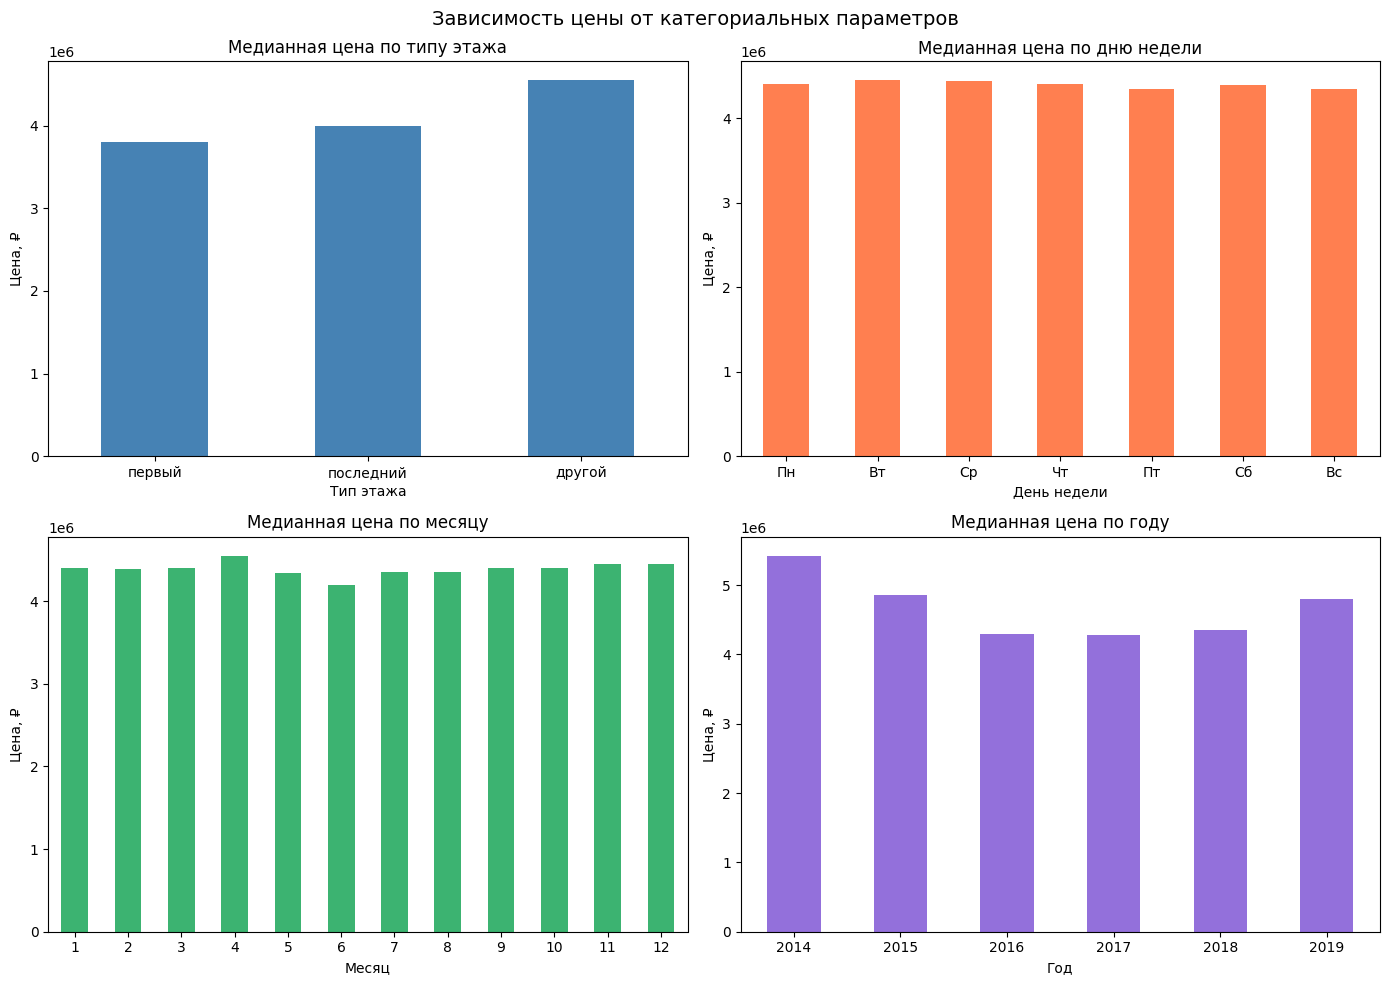

In [22]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Зависимость цены от категориальных параметров', fontsize=14)

# Этаж
floor_order = ['первый', 'последний', 'другой']
df_filtered.groupby('floor_type')['last_price'].median().reindex(floor_order).plot(
    kind='bar', ax=axes[0, 0], color='steelblue')
axes[0, 0].set_title('Медианная цена по типу этажа')
axes[0, 0].set_xlabel('Тип этажа')
axes[0, 0].set_ylabel('Цена, ₽')
axes[0, 0].tick_params(axis='x', rotation=0)

# День недели
days = ['Пн', 'Вт', 'Ср', 'Чт', 'Пт', 'Сб', 'Вс']
df_filtered.groupby('weekday')['last_price'].median().plot(
    kind='bar', ax=axes[0, 1], color='coral')
axes[0, 1].set_title('Медианная цена по дню недели')
axes[0, 1].set_xlabel('День недели')
axes[0, 1].set_ylabel('Цена, ₽')
axes[0, 1].set_xticklabels(days, rotation=0)

# Месяц
df_filtered.groupby('month')['last_price'].median().plot(
    kind='bar', ax=axes[1, 0], color='mediumseagreen')
axes[1, 0].set_title('Медианная цена по месяцу')
axes[1, 0].set_xlabel('Месяц')
axes[1, 0].set_ylabel('Цена, ₽')
axes[1, 0].tick_params(axis='x', rotation=0)

# Год
df_filtered.groupby('year')['last_price'].median().plot(
    kind='bar', ax=axes[1, 1], color='mediumpurple')
axes[1, 1].set_title('Медианная цена по году')
axes[1, 1].set_xlabel('Год')
axes[1, 1].set_ylabel('Цена, ₽')
axes[1, 1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

### Вывод

**Тип этажа** оказывает заметное влияние. Квартиры на средних этажах стоят дороже всего (медиана ~4.55 млн ₽): покупатели ценят их за отсутствие недостатков первого и последнего этажей. Первый этаж наименее привлекателен (~3.8 млн ₽): шум с улицы, отсутствие вида, вопросы безопасности. Последний этаж занимает промежуточное положение (~4.0 млн ₽) — риск протечки кровли в старом фонде снижает спрос.

**День недели и месяц** практически не влияют на цену: разброс медиан минимален. Это логично — цена формируется продавцом заранее и не зависит от даты публикации объявления.

**Год** показывает параболическую динамику: высокие цены в 2014 году сменились спадом в 2016–2018, после чего наметился рост в 2019-м. Это соответствует макроэкономической ситуации в России: девальвация рубля в 2014–2015 годах обвалила реальные цены на недвижимость, а восстановление началось к концу десятилетия.


<a id="6"></a>
## 6. Географический анализ

### 6.1 Цена м² в топ-10 населённых пунктах

Отбираем населённые пункты с наибольшим числом объявлений и сравниваем среднюю цену за м².

In [ ]:
# Топ-10 населённых пунктов по числу объявлений
top_10      = df_filtered['locality_name'].value_counts(ascending=False).head(10)
top_10_list = top_10.index.tolist()
print(top_10)

In [ ]:
# Средняя цена за м² по каждому населённому пункту из топ-10, по убыванию
price_per_sq_m_in_locality = (
    df_filtered
    .query('locality_name in @top_10_list')
    .pivot_table(index='locality_name', values='price_per_sq_m', aggfunc='mean')
    .sort_values('price_per_sq_m', ascending=False)
    .reset_index()
)
display(price_per_sq_m_in_locality)

In [ ]:
price_per_sq_m_in_locality.plot(
    kind='barh', x='locality_name', y='price_per_sq_m',
    figsize=(10, 6), legend=False, color='#f5005a'
)
plt.title('Средняя цена м² в топ-10 населённых пунктах')
plt.xlabel('₽ за м²')
plt.ylabel('')
plt.tight_layout()
plt.show()

### Вывод

Анализ показывает чёткий градиент стоимости жилья от центра к периферии. Лидируют **Санкт-Петербург** (~106 тыс. ₽/м²) и **Пушкин** (~100 тыс. ₽/м²) — исторический статус, транспортная доступность и премиальная застройка объясняют высокие цены. **Кудрово** (~92 тыс. ₽/м²) выбивается из ожидаемого географического порядка: активное девелоперское освоение и близость к КАД подтолкнули цены выше, чем у более близких к городу локаций.

**Парголово** и **Мурино** (~85–90 тыс. ₽/м²) держатся за счёт метро и развитой инфраструктуры. **Шушары** (~79 тыс. ₽/м²) и **Колпино** (~75 тыс. ₽/м²) отстают: в первом случае сказывается промышленное окружение, во втором — отсутствие метро.

Замыкают список удалённые пригороды: **Гатчина** (~69 тыс. ₽/м²), **Всеволожск** (~67 тыс. ₽/м²) и **Выборг** (~58 тыс. ₽/м²). Общий разброс цен между лидером и аутсайдером составляет около **82%** — рынок жилья в регионе сильно территориально дифференцирован.


### 6.2 Зависимость цены от расстояния до центра Санкт-Петербурга

Смотрим, как средняя цена меняется с каждым километром удалённости от центра.

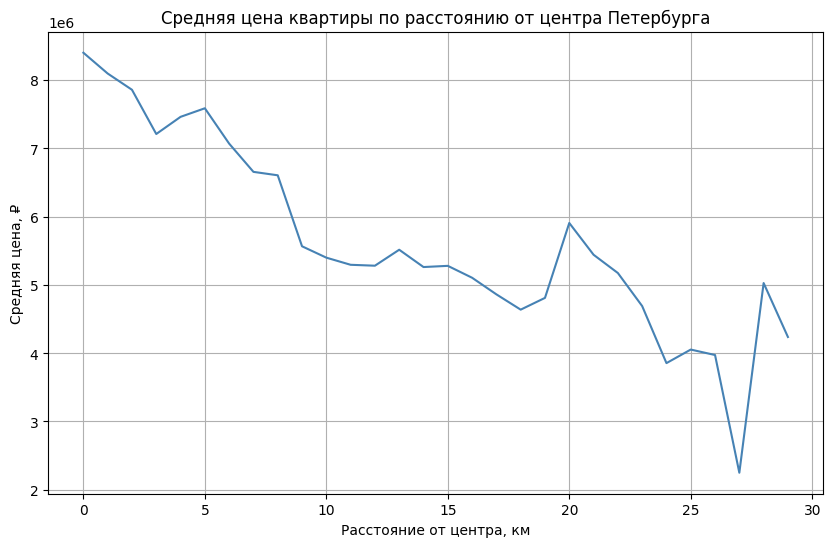

In [28]:
# Выведем для каждого км удаленности от центра в Санкт-Петербурге среднюю цену и построим график зависимости
(df_filtered
            .query('locality_name == "Санкт-Петербург"')
            .assign(distance_in_km=lambda x: (x['cityCenters_nearest'] / 1000).round(0))
            .groupby('distance_in_km')['last_price']
            .mean()
            .plot(figsize=(10, 6), color='steelblue', grid=True)
)
plt.title('Средняя цена квартиры по расстоянию от центра Петербурга')
plt.xlabel('Расстояние от центра, км')
plt.ylabel('Средняя цена, ₽')
plt.show()

### Вывод

График показывает устойчивую отрицательную зависимость цены от удалённости. Выделяются три зоны:

**Центральная (0–8 км):** цена падает с ~8.5 до ~6.5 млн ₽. Резкий перелом на отметке 8 км (~5.6 млн ₽) маркирует границу центра.

**Средняя (8–20 км):** плавное снижение до ~4.6 млн ₽ с небольшими колебаниями. Локальный пик на 20 км (~5.9 млн ₽), вероятно, связан с крупными премиальными новостройками на окраинах.

**Периферия (20–30 км):** цена достигает минимума ~2.2 млн ₽ на 27 км. Резкие скачки на 28–29 км объясняются малым числом наблюдений — делать выводы по ним некорректно.

**Итог:** граница центральной ценовой зоны Санкт-Петербурга проходит примерно на расстоянии **8 км** от географического центра города.


<a id="7"></a>
## 7. Анализ центрального сегмента (≤ 8 км от центра)

Выделяем квартиры в центральной зоне и сравниваем их характеристики с общей базой.

In [ ]:
# Добавляем расстояние до центра в километрах (округляем до целых для группировки)
df_filtered['distance_to_center_km'] = (df_filtered['cityCenters_nearest'] / 1000).round(0)

# Центральная зона: Санкт-Петербург, не далее 8 км от центра
df_center = df_filtered.query('locality_name == "Санкт-Петербург" and distance_to_center_km <= 8')
print(f'Квартир в центральной зоне: {len(df_center)}')

#### Сравнение центра и всей базы

In [ ]:
# Распределения основных параметров для центра
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Распределение основных параметров — центр СПб (≤ 8 км)', fontsize=14)

axes[0, 0].hist(df_center['last_price'],      bins=30, edgecolor='black', color='#1EB145')
axes[0, 0].set_title('Цена')
axes[0, 0].set_xlabel('₽')
axes[0, 0].set_ylabel('Количество')

axes[1, 0].hist(df_center['total_area'],      bins=30, edgecolor='black', color='#3A5EFC')
axes[1, 0].set_title('Площадь')
axes[1, 0].set_xlabel('м²')
axes[1, 0].set_ylabel('Количество')

axes[0, 1].hist(df_center['ceiling_height'],  bins=40, edgecolor='black', color='#F25618')
axes[0, 1].set_title('Высота потолков')
axes[0, 1].set_xlabel('м')
axes[0, 1].set_ylabel('Количество')

axes[1, 1].hist(df_center['rooms'],           bins=20, edgecolor='black', color='#FF65A8')
axes[1, 1].set_title('Число комнат')
axes[1, 1].set_xlabel('комнат')
axes[1, 1].set_ylabel('Количество')

plt.tight_layout()
plt.show()

In [ ]:
# Таблица сравнения медианных значений: центр vs вся база
params = ['total_area', 'last_price', 'rooms', 'ceiling_height']
labels = ['Площадь, м²', 'Цена, ₽', 'Число комнат', 'Высота потолков, м']

print(f"{'Параметр':<25} {'Центр (медиана)':>20} {'Вся база (медиана)':>20} {'Разница, %':>12}")
print('-' * 80)
for col, label in zip(params, labels):
    med_center = df_center[col].median()
    med_all    = df_filtered[col].median()
    diff       = (med_center - med_all) / med_all * 100
    print(f"{label:<25} {med_center:>20,.0f} {med_all:>20,.0f} {diff:>+11.1f}%")

#### Факторы влияния на цену внутри центральной зоны

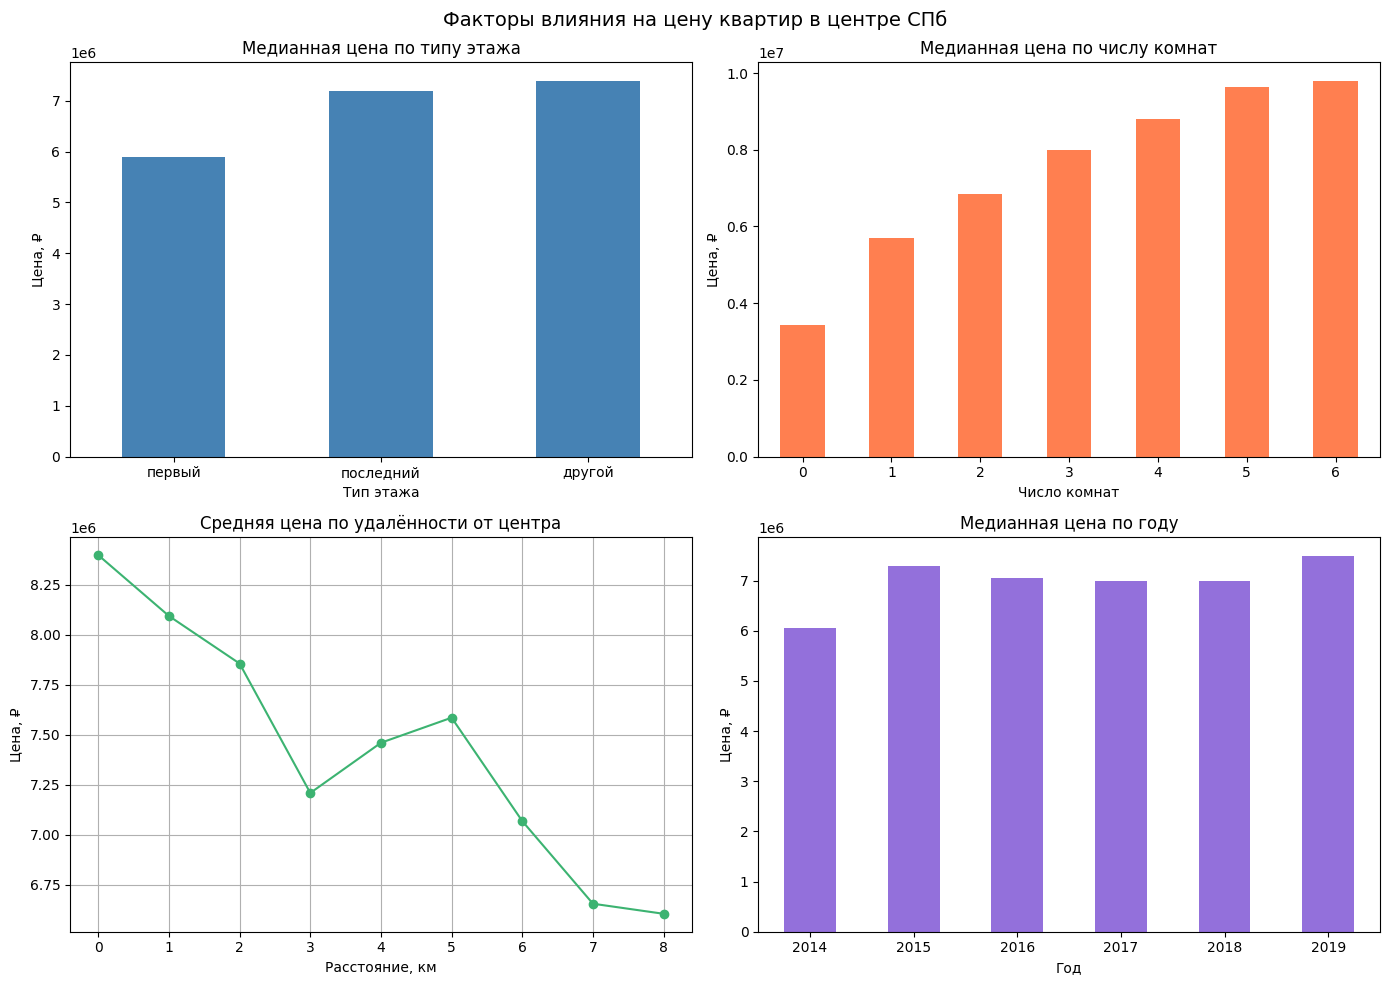

In [ ]:
# Факторы влияния на цену в центре:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Факторы влияния на цену квартир в центре СПб', fontsize=14)

# Этаж
floor_order = ['первый', 'последний', 'другой']
df_center.groupby('floor_type')['last_price'].median().reindex(floor_order).plot(
    kind='bar', ax=axes[0, 0], color='steelblue')
axes[0, 0].set_title('Медианная цена по типу этажа')
axes[0, 0].set_xlabel('Тип этажа')
axes[0, 0].set_ylabel('Цена, ₽')
axes[0, 0].tick_params(axis='x', rotation=0)

# Число комнат
df_center.groupby('rooms')['last_price'].median().plot(
    kind='bar', ax=axes[0, 1], color='coral')
axes[0, 1].set_title('Медианная цена по числу комнат')
axes[0, 1].set_xlabel('Число комнат')
axes[0, 1].set_ylabel('Цена, ₽')
axes[0, 1].tick_params(axis='x', rotation=0)

# Удалённость от центра
df_center.groupby('distance_to_center_km')['last_price'].mean().plot(
    ax=axes[1, 0], color='mediumseagreen', marker='o')
axes[1, 0].set_title('Средняя цена по удалённости от центра')
axes[1, 0].set_xlabel('Расстояние, км')
axes[1, 0].set_ylabel('Цена, ₽')
axes[1, 0].grid(True)

# Год
df_center.groupby('year')['last_price'].median().plot(
    kind='bar', ax=axes[1, 1], color='mediumpurple')
axes[1, 1].set_title('Медианная цена по году')
axes[1, 1].set_xlabel('Год')
axes[1, 1].set_ylabel('Цена, ₽')
axes[1, 1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

### Вывод

Квартиры в центральной зоне (≤ 8 км) заметно отличаются от общей базы:

- **Площадь** в центре выше: медиана ~55 м² против ~45 м² по всей выборке. Это связано с преобладанием старого жилого фонда — сталинок и дореволюционных домов — с просторными планировками.
- **Цена** ожидаемо выше: медиана ~6.5–7 млн ₽ против ~4.5 млн ₽ по всей базе — разрыв порядка 40–50%.
- **Потолки** выше: медиана ~2.8–3.0 м против стандартных 2.65 м, что отражает архитектурные особенности исторической застройки.

По факторам влияния картина в целом повторяет общую, но с нюансами:

- **Этаж:** влияние сохраняется, однако разрыв между типами в центре чуть меньше: в историческом фонде первые этажи дисконтируются не так сильно из-за высоких потолков и архитектурной ценности зданий.
- **Число комнат:** зависимость положительная, как и по всей базе. В центре многокомнатные квартиры дорожают резче — элитный сегмент представлен значительно шире.
- **Удалённость:** внутри центральной зоны каждый километр даёт более ощутимый прирост цены, чем на периферии.
- **Год:** динамика аналогична общей базе, но амплитуда колебаний выше: премиальный сегмент острее реагирует на макроэкономические изменения.


<a id="8"></a>
## 8. Общие выводы

По результатам анализа архива объявлений Яндекс Недвижимости (23 699 записей, СПб и область, 2014–2019).

**Предобработка.** Пропуски в числовых столбцах заполнены медианой. Столбцы с геоданными и `is_apartment` оставлены с пропусками — восстановить их без риска искажений невозможно. `days_exposition` оставлен намеренно: пропуск означает, что квартира не была продана на момент выгрузки (MNAR). Удалено **2 247 записей** с выбросами по площади, цене, числу комнат и высоте потолков (метод IQR; для потолков — содержательный порог 5 м).

---

**Ключевые факторы, влияющие на цену:**

| Фактор | Корреляция | Характер влияния |
|--------|------------|-----------------|
| Площадь | r = +0.70 | Наиболее сильный предиктор |
| Число комнат | r = +0.43 | Слабее площади: маленькая двушка может стоить дешевле большой однушки |
| Удалённость от центра | r = −0.35 | Центральная зона (≤ 8 км) дороже периферии на 40–50% |
| Тип этажа | — | Первый этаж дешевле среднего на ~15%, последний — на ~10% |
| День недели / месяц | — | Не влияют на цену |
| Год публикации | — | Спад в 2015–2018, восстановление в 2019 — следствие девальвации рубля |

---

**Время продажи.** Медиана — **91 день**, среднее — **172 дня**. Продажа за < 45 дней сигнализирует о заниженной цене; > 250 дней — о завышенной или проблемном объекте.

**География.** Среди топ-10 населённых пунктов лидер — Санкт-Петербург (~106 тыс. ₽/м²), аутсайдер — Выборг (~58 тыс. ₽/м²). Разброс ~82% подтверждает высокую территориальную дифференциацию рынка.

**Центральный сегмент (≤ 8 км).** Квартиры крупнее (медиана площади +~20%), дороже (+40–50%) и с более высокими потолками, чем по всей базе. Те же факторы цены, что и на периферии, — но выражены сильнее.
